<a href="https://colab.research.google.com/github/Kristina-RUC/datamana/blob/main/map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Colab is an online place (cloud) for running Python notebooks--we will use it to run our code :)

You can just edit and adjust and and run the notebook I gave you [this file!]: don't forget to first save it!!!: File-Save a copy in GitHub

And after adjusting to run with your own data, you can submit it as ps :)

After making edits, while can diff on GitHub, its clunky, better here: File-Revision History

make webbrowser fullscreen and collapse upper menu (arrow on the right), especially on laptop

There is built in AI Gemini that works well: suggests code (autocomplete in grey), explains error (like stack overflow), and can click on cell menu and Explain (explain the code)

(a sidenote: File-Download it and convert to pdf: https://2pdf.com/convert-ipynb-to-pdf)

In [3]:
%%capture
#!pip install geopandas #==1.0.1
!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [4]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [5]:
#!python --version
gpd.__version__

'1.1.4'

### [sep3] map your area of interest

say you are interested in NJ counties, so just google that geography + "shapefile", i.e., "NJ counties shapefile"

maps have their own files, a popular one is 'shapefile'--have it zipped--one shapefile consists of several files--keep them in one zipped folder and dont change their names

In [6]:
! wget -q -O Census_Block_Groups_2010-shp.zip https://github.com/Kristina-RUC/datamana/raw/refs/heads/main/Census_Block_Groups_2010-shp.zip
!ls

Census_Block_Groups_2010-shp.zip  nj-counties.zip  sample_data


In [7]:
#i found one and reposted on my website, download it onto colab:
! wget -q -O nj-counties.zip https://github.com/Kristina-RUC/datamana/raw/refs/heads/main/Census_Block_Groups_2010-shp.zip

zip_ref = zipfile.ZipFile('Census_Block_Groups_2010-shp.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
!ls #see what we got

njC0=gpd.read_file('Census_Block_Groups_2010-shp.zip') #load the shapefile with gpd as njC0

##lets unpack, also good for debugging! comment out and do line by line

Census_Block_Groups_2010.cpg  Census_Block_Groups_2010.shp	nj-counties.zip
Census_Block_Groups_2010.dbf  Census_Block_Groups_2010-shp.zip	sample_data
Census_Block_Groups_2010.prj  Census_Block_Groups_2010.shx


<Axes: >

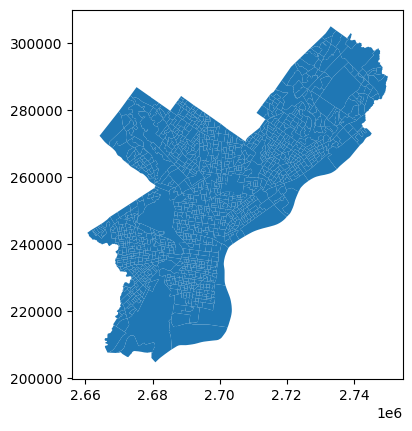

In [8]:
#make the map
njC0.plot()

## <font color='red'> \>will be updated from here\> </font>

### [sep10] dive into thematic/choloropleth maps

 the key skill you will learn--we color code polygons (or lines or points) with levels of a variable, say green for low covid19, yellow for moderate, and red for high


REFS (also good for self study):

https://geographicdata.science/book/notebooks/05_choropleth.html
[like a textbook, good stuff like most by darribas (little wordy tho)]

https://geopandas.org/en/stable/gallery/choropleths.html

https://geopandas.org/en/stable/gallery/choro_legends.html

first, mapping var from gis datafile--rarely lucky and have the variable we want to map already in the shapefile

In [ ]:
! wget -q -O nj-counties.zip https://github.com/theaok/data/raw/refs/heads/main/bounds_nj_shp.zip
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC

In [ ]:
njC0.dtypes #with geopandas can do stuff like with pandas :) need numeric for mapping

In [ ]:
njC0.head(2)

In [ ]:
#keep it simple! always do it! and do it early!
njC=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]

In [ ]:
njC.info() #have a look at the data: how many non-null and dtypes again

In [ ]:
njC.COUNTY.value_counts(dropna=False) #any duplicates or missing

In [ ]:
njC.plot() #yay love the shape

In [ ]:
#THIS IS THE KEY CODE: keep it in mind, come back to it, use it, understand it
#may put lots of comments here too
#first thematic map! lets unpack options esp fmt for dec pts; more later sec 'bells and whistles'
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POPDEN2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
#leg1 = ax.get_legend()
#leg1.set_title('''Population Density #this is legend title; useful!
#2010 (pers/sq mi)''')
ax.title.set_text("Population Density 2010 (pers/sq mi)")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks

ax.margins(0.04) #super useful options to make map bigger in canvas; always make it as big as possible!
#ax.axis('off')
#plt.savefig('fig.pdf',bbox_inches='tight') #,pad_inches=0.1, dpi=200, transparent=True #eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff
#files.download('fig.pdf') #note can also right click fig and save image as

#btw for afficcionados, yes can further adjust the legend:
#https://stackoverflow.com/questions/52503899/format-round-numerical-legend-label-in-geopandas

In [ ]:
# we can overlay layers; lets get nj uni shapefile on it
!wget -q -O col.zip  https://github.com/theaok/data/raw/refs/heads/main/hsip_colleges.zip
zip_ref = zipfile.ZipFile('col.zip', 'r');zip_ref.extractall(); zip_ref.close()

col = gpd.read_file('2007_11_30_NJ_COLL_UNIV_njsp.shp')
col.dtypes
col.head(3)

In [ ]:
col['enr'] = col.ENROLL.astype(float)

In [ ]:
#and now overlay: just use plot fn twice; remember: most maps are layered
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax, color='white', edgecolor='black',linewidth=1)
col.plot(ax=ax, marker='o', color='red', markersize=10,legend=True)
#col.plot(column='enr',markersize=50,legend=True,cmap='RdYlGn_r',scheme='QUANTILES',k=5,ax=ax)
#ax.set_title('Watersheds by area ($mi^2$)')

#custom legend
#https://stackoverflow.com/questions/39500265/how-to-manually-create-a-legend
#import matplotlib.patches as mpatches
#red_patch = mpatches.Patch(color='red', label='The red data')
from matplotlib.lines import Line2D
point = Line2D([0], [0], label='university', marker='o', markersize=3,
         markeredgecolor='r', markerfacecolor='r', linestyle='')
plt.legend(handles=[point])

## [sep17] join/merge

note! need to specify gdf first (left) and then df (right), otherwhise it doesnt recognize resulting df as gdf but df

awesome power! use it a lot

make it easy on yourself--work smart, not hard! so simplify or subset:
say instead of 200 little indian regions just do 20 big provinces; and instead of 50 convoluted variables, just retain 5<br>

merge may get difficult (especially if difficult data so again simplify): if you need more power:

https://colab.research.google.com/github/theaok/datManPy/blob/main/pandas.ipynb#scrollTo=dMPPOPS92WkA

<br>

 <br>we will cover how to map multiple variables in one map later; for now just use 2 separate maps; and calculate new variables! for instance instead of having 2 maps for crime in 1970 and 2000 just have percent difference: 100*(crim2000-crim1970)/crim1970

<br>
dataset of the week:
 https://njoag.app.box.com/s/upgf6yyi9g0fyjg6ednhqmr69dg9crfh

 <br><br>
 map of the week:
 https://maps-dppa.camden.rutgers.edu/index.php?title=Camden_nonprofits

### housing/zillow example

say want to map housing values across nj counties

first get the counties shp (already got it)

now get regular data with housing values and merge with counties shp

and finaly color code the polygons with housing values




#### zillow dat man
(again note can collapse and run all at once)

housing prices for NJ counties (i just googled 'housing prices data') (http://www.zillow.com/research/data):

https://github.com/theaok/data/raw/main/NJ-counties-Zillow-Home-Value-Index-TimeSeries.xls



adjust ID: make counties uppercase (or could drop 'County' from COUNTY LABEL variable)


and clean up:  drop first row if junk in it, excessive columns, \$ \%,\#, etc

code everything so the end product is like:

https://raw.githubusercontent.com/theaok/data/main/all_homes.csv


In [ ]:
zilXls=pd.read_excel('https://github.com/theaok/data/raw/main/NJ-counties-Zillow-Home-Value-Index-TimeSeries.xls')

In [ ]:
zilXls.head(2)

In [ ]:
zilXls.dtypes
#zilXls.info(verbose=True)

In [ ]:
zilXls1=zilXls[['NJ Zillow Home Value Index - All Homes','Unnamed: 203']]
zilXls1.rename(columns={'NJ Zillow Home Value Index - All Homes': 'county'}, inplace=True)
zilXls1.rename(columns={'Unnamed: 203': 'dec2012'}, inplace=True)
zilXls1

In [ ]:
zilXls2=zilXls1.iloc[1:, :] #drop first obs
zilXls2 #note missing val for Morris; always think abt missing data!

In [ ]:
zilXls2['COUNTY']=zilXls2['county'].str.upper()
zil1=zilXls2
zil1

In [ ]:
#obsolete (was loading cleaned up already data without cleaning in py)
#!wget -q -O zillow.csv  https://docs.google.com/uc?id=1Q4tCZT0EfaJP_WGwKcxuPaQ_dDFonW4E&export=download
#!wget -q -O zil0.csv https://raw.githubusercontent.com/theaok/data/main/all_homes.csv
#zil0=pd.read_csv('zil0.csv')
#zil0.head(3)
#zil1=zil0[['UPPER','Dec 2012']]
#zil1.rename(columns={'UPPER': 'COUNTY'}, inplace=True) #fix col names to match 1st dataset
#zil1 #note missing val for Morris; always think abt missing data!

#### zillow merge and map

In [ ]:
#merge
njC1 = pd.merge(njC, zil1, on='COUNTY',how='outer',indicator=True) #(make sure to have njC shapefile from previous sec)
njC1[['COUNTY','dec2012','POPDEN2010','_merge']] #all good, NEW JERSEY expected not to merge
#!!!always inwestigate the merge result and always briefly explain it!!!

In [ ]:
njC2 = pd.merge(njC, zil1, on='COUNTY',how='inner',indicator=False) #so do 'inner' that will only keep the exact matches

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC2.plot(ax=ax,column='dec2012',legend=True,cmap='RdYlGn_r',
          scheme='natural_breaks',k=5, edgecolor='grey',linewidth=2,
          legend_kwds= {"fmt": "{:,.0f}",'loc':'lower right','markerscale':1.4})
leg1 = ax.get_legend()
leg1.set_title('''white color=missing''')
ax.title.set_text("Zillow Home Value Index")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/definition: zillow.com/research/data''')
#plt.savefig('fig.pdf',bbox_inches='tight') #,pad_inches=0.1, dpi=200, transparent=True #eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff
#files.download('fig.pdf') #note can also right click fig and save image as

###  abortions example

In [ ]:
#as of sep2025 this download doesnt work anymore

# get data: https://data.guttmacher.org/ has a nice API
# can click thru to get the table we want, which results in url (can open in webbrowser):
# https://data.guttmacher.org/counties/table?county=34001+34003+34005+34007+34009+34011+34013+34015+34017+34019+34021+34023+34025+34027+34029+34031+34033+34035+34037+34039+34041&topics=244+247&dataset=data&state=NJ
# and then can right click on 'download xls' (csv is messy in this case) button under the table and 'copy link address' and paste into wget (need quotes!):
#!wget -q -O njAb0.xls  "https://data.guttmacher.org/download?locationType=county&visualization=datatable&topic=244+247&locations=34001+34003+34005+34007+34009+34011+34013+34015+34017+34019+34021+34023+34025+34027+34029+34031+34033+34035+34037+34039+34041&measures=424+425+426+427+428+429+436+437+438+439+440+441+442&totalKey=NJ"

# alternatively can scrap the table
#import requests
#url = 'https://data.guttmacher.org/counties/table?county=34001+34003+34005+34007+34009+34011+34013+34015+34017+34019+34021+34023+34025+34027+34029+34031+34033+34035+34037+34039+34041&topics=244+247&dataset=data&state=NJ'
#header = {
#  "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.75 Safari/537.36",
#  "X-Requested-With": "XMLHttpRequest"
#}
#r = requests.get(url, headers=header)
#pd.read_html(r.text,match='U.S. County',flavor=None)[0].head(3) #for match just putting name of first col

#njAb0=pd.read_excel('njAb0.xls')
#njAb0.head(3)
#njAb0.columns
#njAb=njAb0[['U.S. County','Total publicly funded clinics, 2015 [1]']] #keep it simple

In [ ]:
njAb=pd.read_csv('https://raw.githubusercontent.com/theaok/data/refs/heads/main/abortions.csv')
njAb.rename(columns={'COUNTY': 'U.S. County'}, inplace=True)
njAb.head(3)

In [ ]:
#look at shapefile cnty names
njC.COUNTY_LAB #(make sure to have njC shapefile from previous sec)

In [ ]:
njC['U.S. County']=njC['COUNTY_LAB'].str.replace(' County','') #get rid of ' County' [note space in front of county]
njC['U.S. County']=njC['U.S. County'].str.upper() #make uppercase
njC['U.S. County'].head(3)

In [ ]:
njCAb = pd.merge(njC, njAb, on='U.S. County',how='outer',indicator=True)
njCAb[['COUNTY','Total publicly funded clinics, 2015 [1]','_merge']].head(50) # ok
#njCAb = pd.merge(njC, njAb, on='U.S. County',how='inner',indicator=True) #inner merge
#njCAb

In [ ]:
njCAb.dtypes

In [ ]:
#often (not here) need to convert string (object) to numeric (float or int; float is safer can have decimals if needed)
njCAb['publicly funded clinics, 2015'] = njCAb['Total publicly funded clinics, 2015 [1]'].astype(float)

In [ ]:
njCAb[['U.S. County','Total publicly funded clinics, 2015 [1]','publicly funded clinics, 2015']]

In [ ]:
fig, ax = plt.subplots(figsize=(6,10))

njCAb.plot(ax=ax,figsize=(10,12),column='publicly funded clinics, 2015',legend=True,cmap='RdYlGn_r',
          scheme='natural_breaks',k=5, edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}"})
#ax.set_xticks([]) #kills xticks
#ax.set_yticks([]) #kills xticks
ax.set_title('count of publicly funded abortion clinics, 2015')
#ax.annotate('Note added to chart with minimum parameters', xy = (200000, 1000))
plt.figtext(0.5, 0.1,
            '''data from guttmacher.org
            Publicly Funded Contraceptive Services at U.S. Clinics, 2015, Frost JJ, et al., 2017''',
            ha="center", fontsize=8, #bbox={"facecolor":"white", "alpha":0.5, "pad":5}
            )

### [sep17] us census data example

census is a great source of data, even at neigh lev!

for neigh lev (census tracts)  want 5-yr ACS (so that the standard errors on estimates for these tiny areas are not too huge)

https://geomap.ffiec.gov/FFIECGeocMap/GeocodeMap1.aspx


SKIP (instead do user-friendly socialexplorer below):

https://data.census.gov/cedsci/advanced

Geography: Tract: New Jersey: Camden County: All Census Tracts within Camden County

note: selection appears in the left panel

Topics: Income and Poverty: Poverty: Official Poverty Measure

Years: 2015

Search

click ``POVERTY STATUS IN THE PAST 12 MONTHS''  (ACS2011-2015 S1701)

(take note of margins of errors)

sure can transpose and download as csv but its a mess!




one rule to guide us is to be lazy/work smart, not hard

just find a decent alternative to clunky/messy census such as:

socialexplorer.com (free on-campus or vpn)

Tables: ACS 2015-2019

SE:A13003B. Poverty Status in 2019 for Population Age 18 to 64

tracts in camden county nj

downloaded as csv and reposted:
https://raw.githubusercontent.com/theaok/data/main/R13437109_SL140.csv



In [ ]:
!wget -q -O pov0.csv https://raw.githubusercontent.com/theaok/data/main/R13437109_SL140.csv

pov0=pd.read_csv('pov0.csv')
pov0.head(3)

In [ ]:
#as per the above documentation we see percent poor is
#number of poor people divided by population: SE_A13003B_002/SE_A13003B_001
pov0['pov']=(pov0.SE_A13003B_002/pov0.SE_A13003B_001)*100
pov=pov0[['pov','Geo_NAME']]
pov

get geo data

https://www.census.gov/geo/maps-data/data/tiger-line.html

Download-Web Interface: 2019: Census Tracts: New Jersey

reposted:
https://github.com/theaok/data/raw/main/tl_2019_34_tract.zip

In [ ]:
! wget -q -O tracts.zip https://github.com/theaok/data/raw/main/tl_2019_34_tract.zip
zip_ref = zipfile.ZipFile('tracts.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
#! ls
tracts=gpd.read_file('tl_2019_34_tract.shp')

In [ ]:
#%%capture
tracts.plot() #humongous, thousands of tracts!

In [ ]:
tracts.dtypes

In [ ]:
#tracts.head(3) #commented out because a lot of output; but have a look: geometries: x/y or lat/lon

In [ ]:
tracts["COUNTYFP"].value_counts(dropna=False)

google county codes:

https://www.google.com/search?client=firefox-b-1-d&q=nj+counties+fips+codes

https://en.wikipedia.org/wiki/List_of_counties_in_New_Jersey

In [ ]:
tractsCam=tracts[tracts.COUNTYFP=='007']

In [ ]:
tractsCam.plot() #yay

In [ ]:
tractsCam.NAMELSAD

In [ ]:
a1 = pd.merge(tractsCam, pov, left_on='NAMELSAD', right_on='Geo_NAME',how='outer',indicator=True)

In [ ]:
a1['_merge'].value_counts() #yay

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
a1.plot(ax=ax,column='pov',legend=True,cmap='RdYlGn_r',
          scheme='natural_breaks',k=5, edgecolor='grey',linewidth=.5,legend_kwds= {"fmt": "{:,.0f}"})
ax.title.set_text("Percent in poverty")
ax.set_xticks([]) #kills xticks
ax.set_yticks([]) #kills xticks
ax.set_xlabel('''source/var def: socialexplorer.com/tables/ACS2019_5yr/R13437109''')

### Camden block gr clip ex
https://colab.research.google.com/drive/1OkxSonnQ41OkJqBcNJ8-_8y8Jn1BxW0W?usp=sharing

# [oct1] bells n' whistles (geoprocessing)

we did basic easy mapping, but there's more to it

everyone needs schemes (classification), and the rest just pick what's useful for you!


### schemes (classification)

elaboration and details:
https://geographicdata.science/book/notebooks/05_choropleth.html

(['boxplot', 'equalinterval', 'fisherjenks', 'fisherjenkssampled', 'headtailbreaks', 'jenkscaspall', 'jenkscaspallforced', 'jenkscaspallsampled', 'maxp', 'maximumbreaks', 'naturalbreaks', 'quantiles', 'percentiles', 'prettybreaks', 'stdmean', 'userdefined'])

In [ ]:
njC.plot(column='POPDEN2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})

In [ ]:
#do think how distribution translate into colors!!
#njC.POPDEN2010.hist(bins=10) #super skewed!
ax = sns.histplot(njC["POPDEN2010"], bins=10)
sns.rugplot(njC["POPDEN2010"], height=0.05, color="red", ax=ax);

In [ ]:
#your own classification: 2k looks like good cutoff, then 4k and 7k
njC.plot(column="POPDEN2010", scheme="user_defined", cmap="YlOrRd", classification_kwds={'bins':[2000, 4000, 7000]},
         linewidth=1,edgecolor='white', legend=True,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})


In [ ]:
njC.POPDEN2010.sort_values()
#note the bin is upto val with it; and next one is from it without it
njC.plot(column="POPDEN2010", scheme="user_defined", cmap="YlOrRd", classification_kwds={'bins':[2000, 4000, 6044]},
         linewidth=.2,edgecolor='grey', legend=True,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})

### simplify geo

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp')
njC=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]

In [ ]:
njC.dtypes

In [ ]:
njC.plot(figsize=(12,24), color='white', edgecolor='black',linewidth=.2)

In [ ]:
njC1=njC.copy()
njC1['geometry'] = njC1.simplify(tolerance=2000)
njC1.plot(figsize=(12,24), color='white', edgecolor='black',linewidth=.5)
njC.to_file('njC.kml', driver='KML')
njC1.to_file('njC1.kml', driver='KML')
! ls -lah *.kml #37k v 6.5m!!!

In [ ]:
#TODO checkout new
#gdf.simplify_coverage(tolerance=10)


### I/O
(in gpd < 1 was fiona, now pyogrio (both gdal wrappers); btw command line ogr2ogr super powerfull)

gdal is the library for i/o!!!!

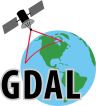

In [ ]:
#%%capture
#!pip install fiona

In [ ]:
#import fiona
# bunch of available drivers are unexposed but supported (depends on the GDAL-build)
# https://github.com/Toblerity/Fiona/blob/main/fiona/drvsupport.py
# https://gdal.org/en/stable/drivers/vector/index.html
# can activate these on runtime by updating the supported_drivers dictionary:
# fiona.supported_drivers["NAS"] = "raw"
#fiona.supported_drivers['KML'] = 'rw'
#fiona.supported_drivers

In [ ]:
import pyogrio; pyogrio.list_drivers()

In [ ]:
!wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp')
njC01=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]

njC=njC01.copy()
njC['geometry'] = njC.simplify(tolerance=2000) #simplify geo (sec above)--important for online mapping
#njC.plot(figsize=(6,12), color='white', edgecolor='black',linewidth=1)

In [ ]:
njC.to_file('njC.kml', driver='KML')
!head -25 njC.kml #go to:
#https://www.google.com/maps/d/
#hit create new map and hit Import under layers at top right

In [ ]:
njC.to_file('njC.geojson', driver='GeoJSON')
!head -10 njC.geojson #coords in weird format

In [ ]:
a=gpd.read_file('njC.geojson')
a.plot() #works fine in gpd

In [ ]:
with open('test.geojson', 'w') as f:
    f.write(njC.to_json(to_wgs84=True))
!head test.geojson #proper coordinates now :)

In [ ]:
import folium as f #https://colab.research.google.com/github/theaok/gisPy/blob/main/folium.ipynb
map = f.Map()
f.GeoJson('test.geojson').add_to(map)
map

In [ ]:
#TODO checkout new
#Fast I/O (pyogrio): Support for engine="pyogrio" in read_file for significantly faster reading/writing of GIS files.

### geocoding

geocode=turn street address into coords

https://automating-gis-processes.github.io/CSC/notebooks/L3/Geocoding_in_Geopandas.html

In [ ]:
df=pd.read_csv('https://github.com/theaok/data/raw/main/addresses.txt',sep=';')
df=df[0:5]
df

In [ ]:
from geopandas.tools import geocode

In [ ]:
#change adam to your name
geo = geocode(df['addr'], provider='nominatim', user_agent='adam',timeout=2)
geo.head(2)

In [ ]:
geo.plot()

### map x y ( lat lon)

https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html

In [ ]:
df = pd.DataFrame(
    {
        "City": ["Buenos Aires", "Brasilia", "Santiago", "Bogota", "Caracas"],
        "Country": ["Argentina", "Brazil", "Chile", "Colombia", "Venezuela"],
        "Latitude": [-34.58, -15.78, -33.45, 4.60, 10.48],
        "Longitude": [-58.66, -47.91, -70.66, -74.08, -66.86],
    }
)
df

In [ ]:
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude) #, crs="EPSG:4326"
)
#note the projection, may try with or without it: crs;
#if things map like in ocean or antarctica, email listserv

In [ ]:
gdf.plot()

###  subset shapefile

super duper popular actually--often much more easier to get data at larger area, eg good luck finding atlantic county munis, but can easily get nj munis, then just subset to atlantic; or indeed can make your own shapefile, eg there's no shapefile for south jersey, but you can make one from new jersey

In [ ]:
!wget -q -O us.zip https://github.com/theaok/data/raw/main/cb_2018_us_state_500k.zip
zip_ref = zipfile.ZipFile('us.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping

In [ ]:
us=gpd.read_file('cb_2018_us_state_500k.shp')
us.plot()

In [ ]:
cont = us[~us['NAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico','American Samoa','United States Virgin Islands','Guam','Commonwealth of the Northern Mariana Islands'])]
cont.plot()

or just google for what you want; even possibly with inset :)

https://www.google.com/search?client=firefox-b-1-d&q=uss+hapefile+alaska+perto+rico+inset

or as now other formats are becoming more popular use kml or GeoPackage:

https://www.google.com/search?client=firefox-b-1-d&q=coniguous+us+states+kml


### aggregate data: groupby+agg

make sure stuff matches 1:1, not 1:many, eg when you merge uni to counties, thats many:1, many uni per 1 county, need to aggregate first to a summary stats like sum!

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC

In [ ]:
!wget -q -O col.zip  https://docs.google.com/uc?id=1bb9KES6QDE7cleE4L38yQ7939LlXUHB5&export=download
zip_ref = zipfile.ZipFile('col.zip', 'r');zip_ref.extractall(); zip_ref.close()

col0 = gpd.read_file('2007_11_30_NJ_COLL_UNIV_njsp.shp')
col0.dtypes
col0.head(3)

In [ ]:
col=col0[['COUNTY','NAME','ENROLL']]
#col
col.ENROLL=col.ENROLL.astype(float)
col.sort_values(by='COUNTY',inplace=True)
col

In [ ]:
colAgg=col.groupby('COUNTY').agg('sum')
colAgg
6845+7035==13880  #double check from previous table

#then can merge and map :)

### standardize and finer resolution

<b>standardize</b> cant compare apple to oranges, divide by area or population, eg wind turbines per sq km; crime per 100k

<b>finer resolution</b>
remember maup problem from slides? ie phenomena (crime, wind turbines, etc) are not evenly distributed across space, so say you have county and you color code it for some level of crime or wind turbines and it makes it look as if it is all uniform across county, but it isnt! map at finer resolution! do municiplaities, or even neighborhoods; or actual points where crime happened or wind turbine sits

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC
njC=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','SQ_MILES','geometry']]

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population 2010 (pers)")
ax.set_xticks([]); ax.set_yticks([])

In [ ]:
njC['popDen10']=njC.POP2010/njC.SQ_MILES

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='popDen10',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population Density 2010 (pers/sq mi)")
ax.set_xticks([]); ax.set_yticks([])

In [ ]:
njM0=gpd.read_file('nj_munis.shp')
njM=njM0[['COUNTY','POP2010','POPDEN2010','SQ_MILES','geometry']]

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njM.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population 2010 (pers)")
ax.set_xticks([]); ax.set_yticks([])

### side-by-side and overlay

helpful all the time; usually want to have some side-by-sides for comparison

almost always do overlays! that's bread and butter of mapping; just be clean dont clutter

In [ ]:
#side-by-side: subplots 1row,2col; then just axs[0] and axs[1]
fig, axs = plt.subplots(1,2, figsize=(10,10),sharey=True, tight_layout=True)
njC.plot(ax=axs[0],column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
axs[0].title.set_text("Population 2010 (pers)")
axs[0].set_xticks([]); axs[0].set_yticks([])

njM.plot(ax=axs[1],column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
axs[1].title.set_text("Population 2010 (pers)")
axs[1].set_xticks([]); axs[1].set_yticks([])

In [ ]:
#overlay: just keep adding on the same ax
fig, ax = plt.subplots(1, figsize=(6,10))
njM.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})
njC.plot(ax=ax,edgecolor='blue',linewidth=1, facecolor="none") #alpha=0.1)

to overlay 2 thematic polygon layers, probably cleanest to just have 2 cat eg yes/no for the overlay, or maybe max 3 cat say lo, med, and hi



In [ ]:
njC.COUNTY #say we want to overlay camden and cumberland

In [ ]:
#first, subset to some interesting area, and then overlay that
njC_cam_cum=njC.query("COUNTY=='CAMDEN' | COUNTY=='CUMBERLAND'")

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=3,
         edgecolor='grey',linewidth=0.2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})

#just like subset and hash or dot
#njC_cam_cum.plot(ax=ax,edgecolor='blue',linewidth=2, facecolor="none",alpha=1)
#njC_cam_cum.plot(ax=ax,edgecolor='blue',linewidth=2, facecolor="none",alpha=1,hatch='/')
njC_cam_cum.plot(ax=ax,edgecolor='blue',linewidth=2, facecolor="none",alpha=1,hatch='///')
'''
/   - diagonal hatching
\   - back diagonal
|   - vertical
-   - horizontal
+   - crossed
x   - crossed diagonal
o   - small circle
O   - large circle
.   - dots
*   - stars
'''

l1 = ax.get_legend()
l1.set_title('''pop 2010''')

import matplotlib.patches as mpatches

bluePatch = mpatches.Patch(edgecolor='blue', facecolor='none',
                     hatch='///', label=r'some condition')

l2=plt.legend(handles=[bluePatch],loc='lower left')

ax.add_artist(l2)
ax.add_artist(l1)


#njC.plot(ax=ax,edgecolor='blue',linewidth=1, facecolor="none") #alpha=0.1)

In [ ]:
#overlay with points, same as earlier under sec: dive into...
!wget -q -O col.zip  https://docs.google.com/uc?id=1bb9KES6QDE7cleE4L38yQ7939LlXUHB5&export=download
zip_ref = zipfile.ZipFile('col.zip', 'r');zip_ref.extractall(); zip_ref.close()

col = gpd.read_file('2007_11_30_NJ_COLL_UNIV_njsp.shp')

#overlay: just use plot fn twice
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax, color='white', edgecolor='black',linewidth=1)
col.plot(ax=ax, marker='o', color='red', markersize=10,legend=True)
#col.plot(column='enr',markersize=50,legend=True,cmap='RdYlGn_r',scheme='QUANTILES',k=5,ax=ax)
#ax.set_title('Watersheds by area ($mi^2$)')

#custom legend
#https://stackoverflow.com/questions/39500265/how-to-manually-create-a-legend
#import matplotlib.patches as mpatches
#red_patch = mpatches.Patch(color='red', label='The red data')
from matplotlib.lines import Line2D
point = Line2D([0], [0], label='university', marker='o', markersize=3,
         markeredgecolor='r', markerfacecolor='r', linestyle='')
plt.legend(handles=[point])

In [ ]:
#from pandas.core.interchange.dataframe_protocol import Column
!wget -q -O col.zip  https://docs.google.com/uc?id=1bb9KES6QDE7cleE4L38yQ7939LlXUHB5&export=download
zip_ref = zipfile.ZipFile('col.zip', 'r');zip_ref.extractall(); zip_ref.close()

col = gpd.read_file('2007_11_30_NJ_COLL_UNIV_njsp.shp')

#overlay: just use plot fn twice
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax, color='white', edgecolor='black',linewidth=1)
col.plot(ax=ax, marker='o',markersize=50,legend=True,column='NAICSDESCR',
         legend_kwds= {
        'loc':'lower left','title_fontsize':'medium','fontsize':'xx-small','markerscale':1.0})
#ok first stab, but too cluttered; group into like say max 5 cats

#### add to canvas anything: turn anything into img eg pd styler

not really necessary unless you are bored

In [ ]:
%%capture
!pip install imgkit
!sudo apt-get install wkhtmltopdf
import imgkit

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC

njC=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]


In [ ]:
njCs = njC[['COUNTY','POP2010']].sort_values(by='POP2010', ascending=False)
sty = njCs.style.background_gradient(cmap='YlOrRd')
sty

In [ ]:
imgkit.from_string(sty.to_html(), 'sty.jpg')

import matplotlib.image as mpimg
img = mpimg.imread('sty.jpg')
plt.imshow(img)

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(10,5),tight_layout=True)
njC.plot(ax=axs[0],column='POP2010',legend=True,cmap='YlOrRd',#scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=0.2,
         #legend_kwds= {"fmt": "{:,.0f}", 'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}
         ) #
axs[0].title.set_text("Population 2010 (pers)")
axs[0].set_xticks([]); axs[0].set_yticks([])

axs[1].imshow(img,aspect='auto') #,  extent=[0,1,0,1]  aspect=3.5
axs[1].set_axis_off()
axs[1].set_xticks([]); axs[1].set_yticks([])

### centroids thematic maps

In [ ]:
njP = njC.copy()

njP["geometry"] = njP["geometry"].centroid

In [ ]:
njP.head(3)

In [ ]:
njP.plot()

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njP.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='black',linewidth=1,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4},
         markersize = 200) #
ax.title.set_text("Population 2010 (pers)")
ax.set_xticks([]); ax.set_yticks([])

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='black',linewidth=1,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower left','title_fontsize':'medium','fontsize':'small','markerscale':1.4})

l1 = ax.get_legend()
l1.set_title('''count''')

njP.plot(ax=ax,column='POPDEN2010',legend=True,cmap='Blues',scheme='natural_breaks',k=5,
         edgecolor='black',linewidth=1,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4},
         markersize = 200) #

ax.title.set_text("Population 2010")
ax.set_xticks([]); ax.set_yticks([])

l2 = ax.get_legend()
l2.set_title('''density''')



ax.add_artist(l2)
ax.add_artist(l1)

### edgecolors

fancy! artistic!

In [ ]:
#https://colab.research.google.com/github/hbeck118/GIS/blob/main/ps3_final.ipynb#scrollTo=Vlg-X8y1_pQW&line=21&uniqifier=1
#TODO get legend working as in above reference
import matplotlib.colors as mcolors

#TODO: simplify
norm = mcolors.Normalize(vmin=njC['POP2010'].min(),
                         vmax=njC['POP2010'].max())
edgecolors = plt.cm.RdYlGn_r(norm(njC['POP2010'].values))

fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,edgecolor=edgecolors,alpha=1, linewidth=5, facecolor="none") #
ax.title.set_text("Population 2010 (pers)")
#the limitation is edges overlap,and having them transparent doesnt help much;
#but can see the other color a tincy bit around the line

### annotate

yes! want to do pretty much always with your final map, does help with storytelling

In [ ]:
#u/a labels: basic and useful thing to do
from matplotlib.patheffects import withStroke
ax=njC.plot() #https://stackoverflow.com/questions/38899190/geopandas-label-polygons
for x, y, label in zip(njP.geometry.x, njP.geometry.y, njP.COUNTY):
    ax.annotate(label, xy=(x, y),horizontalalignment='center',
    fontsize=5,color='black', #fontweight='bold',
    path_effects=[withStroke(linewidth=3, foreground='white')]) #ytext=(3, 3), textcoords="offset points"

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population 2010 (pers)")

ax.text(400000, 800000, r'blah', fontsize=14, color='green')
ax.text(400000, 130000, r'cape may', fontsize=14, color='purple')

from matplotlib.patches import Ellipse
e1 = Ellipse(xy=(400000, 800000), width=200000, height=300000, edgecolor='g', fc='None', lw=1)
ax.add_patch(e1)

In [ ]:
#emoji
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POP2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4}) #
ax.title.set_text("Population 2010 (pers)")

ax.text(400000, 800000, r'❤', fontsize=70,color='red')
#ax.text(400000, 800000, r'👽', fontsize=70,color='red') #can just google emoji, eg https://www.google.com/search?q=emoji+alien%27&rlz=1CAHWSA_enUS1125US1125&oq=emoji+alien%27&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQABiABDIHCAIQABiABDIHCAMQABiABDIHCAQQABiABDIHCAUQABiABDIHCAYQABiABDIICAcQABgWGB4yCAgIEAAYFhgeMggICRAAGBYYHtIBCDQ2NzZqMGo3qAIAsAIA&sourceid=chrome&ie=UTF-8
#some more fancy ones like alien may not render

more info on annotations eg how to add arrow and format annotations:
https://colab.research.google.com/github/theaok/vis/blob/main/all.ipynb#scrollTo=q00k6rAZ8tXo

### [fa25: nov19] mapclassify under the hood

mapclassify we've been using since day 1 in gpd is actually a part of pysal

the whole thing (colors in map) stems from how we bin data--so extra time on details here is useful

In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #load the shapefile with gpd as njC
njC=njC0[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]

In [ ]:
fig, ax = plt.subplots(1, figsize=(6,10))
njC.plot(ax=ax,column='POPDEN2010',legend=True,cmap='YlOrRd',scheme='natural_breaks',k=5,
         edgecolor='grey',linewidth=2,legend_kwds= {"fmt": "{:,.0f}",
        'loc':'lower right','title_fontsize':'medium','fontsize':'small','markerscale':1.4})

In [ ]:
#https://github.com/pysal/mapclassify
bins =  mapclassify.NaturalBreaks(njC['POPDEN2010'], k=5)
bins
#bins.bins
#bins.counts
#bins.get_legend_classes()

#again and again do pay attention to bins! their span and counts inside

#() enpoints not incl
#[] enpoints incl
#eg 6044 is excluded from top interval

In [ ]:
njC['COUNTY']

In [ ]:
bins.classes #these are the obs in each bin


In [ ]:
#mapclassify.util.get_color_array(njC.POPDEN2010, scheme='natural_breaks', cmap='YlOrRd')
hex=mapclassify.util.get_color_array(
    njC.POPDEN2010, scheme="natural_breaks", cmap="YlOrRd", as_hex=True
)
hex

In [ ]:
#see how many obs and set # of bins to that number +1
njC.shape[0]

In [ ]:
ax = sns.histplot(njC["POPDEN2010"], bins=22) #one more bin than obs
sns.rugplot(njC["POPDEN2010"], height=0.05, color="red", ax=ax);

In [ ]:
bins.plot_histogram(color='green',edgecolor='green',bins=22)
#vert line denotes top cutoff for each bin
#note: it does incl whatever even partially is before it
#first bar crsses over the line, but part of it presedees it
# same third bar with 2nd line--these 2obs along with 4 on 2nd bar are in 2nd bin which contains 6obs

In [ ]:
ax=bins.plot_histogram(color='green',edgecolor='green',bins=22)
sns.rugplot(njC["POPDEN2010"], height=0.05, color="red", ax=ax);

In [ ]:
njC["POPDEN2010"].sort_values() # eg 6044 is excluded from top interval

In [ ]:
#zoom in onto lower classes
njC3=njC[njC['POPDEN2010']<3000]
bins3 =  mapclassify.NaturalBreaks(njC3['POPDEN2010'], k=5)
ax=bins3.plot_histogram(color='green',edgecolor='green',bins=22)
sns.rugplot(njC3["POPDEN2010"], height=0.05, color="red", ax=ax);

LATER
ok and the following i got the colors from the map, and i was trying to make a histogram with them, but still trying



In [ ]:
from IPython.display import HTML, display
def disHex(hex_color):
    return HTML(f'<div style="width: 50px; height: 50px; background-color: {hex_color}; border: 1px solid black;"></div>')

display(disHex("#FFC300"))

In [ ]:
import numpy as np
np.unique(hex)


In [ ]:
np.unique(hex)[0]


In [ ]:

display(disHex(np.unique(hex)[4]))
#disHex(np.unique(hex)[0])

### basemap (contextily)

https://geopandas.org/en/stable/gallery/plotting_basemap_background.html

they change quite a bit options and basemaps  https://contextily.readthedocs.io/

gallery: https://xyzservices.readthedocs.io/en/stable/gallery.html
 (most dont seem to work)
<br>for interactive mapping (zoom, move, popup) we will use folium/leaflet

In [ ]:
%%capture
! pip install contextily --upgrade
import contextily as cx
#cx.providers

In [ ]:
%%capture
###may break! comment out capture to see output, note just this cell is like 3mb!!

#njC = njC.to_crs(epsg=3857)
ax = njC.plot(figsize=(10, 20),facecolor='none',lw=2 , edgecolor='red') #alpha=0.5  zoom=12
#cx.add_basemap(ax,crs=njC.crs,source=cx.providers.USGS.USTopo)
#cx.add_basemap(ax,crs=njC.crs,source=cx.providers.OpenStreetMap.Mapnik)
cx.add_basemap(ax,crs=njC.crs,source=cx.providers.OpenTopoMap)
#cx.add_basemap(ax,crs=njC.crs, source=cx.providers.CartoDB.PositronNoLabels)
#cx.add_basemap(ax,crs=njC.crs, source=cx.providers.CartoDB.Voyager)
#cx.add_basemap(ax,crs=njC.crs, source=cx.providers.CartoDB.VoyagerNoLabels)
ax.set_axis_off()

### interactive and heat maps [skip]

https://geopandas.org/en/stable/docs/user_guide/interactive_mapping.html

https://nbviewer.org/gist/perrygeo/c426355e40037c452434 (heatmaps)

<br>we will use folium/leaflet later instead

<br>but here just a teaser, as of 2026 gpd can do leaflet

In [ ]:
#Interactive Visualization (explore): Native interactive mapping with leafet.js, allowing tooltips, popups, and basemaps.
njC.explore(column="POP2010", tooltip=True)

### [*] dissolve

In [ ]:
!wget -q -O IND.zip https://github.com/theaok/data/raw/main/GIS-INDIA-MAP.zip
zip_ref = zipfile.ZipFile('IND.zip', 'r'); zip_ref.extractall(); zip_ref.close()
i = gpd.read_file('INDIA-MAP.shp')

In [ ]:
i.shape #wow its a lot

In [ ]:
i.plot()

In [ ]:
states = i.dissolve(by='statename',aggfunc='sum').reset_index()
states = states[['statename', 'distarea', 'totalpopul','totpopmale', 'totpopfema', 'geometry']]
states['statename'] = states['statename'].str.upper()

In [ ]:
states.plot()

### [*] projections

skip but if things get weird--mutated shapes, NJ in Pacific, then you have a projection problem

https://automating-gis-processes.github.io/CSC/notebooks/L2/projections.html

In [ ]:
!wget -q -O us.zip https://github.com/theaok/data/raw/main/cb_2018_us_state_500k.zip
zip_ref = zipfile.ZipFile('us.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
us=gpd.read_file('cb_2018_us_state_500k.shp')
#us.plot()
cont = us[~us['NAME'].isin(['Alaska', 'Hawaii', 'Puerto Rico','American Samoa','United States Virgin Islands','Guam','Commonwealth of the Northern Mariana Islands'])]
cont.plot()

In [ ]:
cont.crs

In [ ]:
cont.to_crs(epsg=3035).plot()

In [ ]:
#TODO checkout new
#Coordinates Support: Added has_m and include_m support, enabling management of measure values in geometries.

### [*] point in polygon/intersect, spatial join, nearest neighb

https://automating-gis-processes.github.io/CSC/notebooks/L4/Point-in-polygon.html

https://automating-gis-processes.github.io/CSC/notebooks/L4/spatial-join.html

https://automating-gis-processes.github.io/CSC/notebooks/L4/nearest-neighbour.html


TODO checkout new:
Improved Spatial Joins (sjoin_nearest): Finds nearest features with maximum radius support

### [*] https://towardsdatascience.com/how-to-make-proximity-maps-with-python-da398788e058/

# [oct8] other vis than gis/maps

it's gis--vis with maps, but do other vis too!

In [ ]:
import seaborn as sns #quick pretty wrapper on mpl
import plotly.express as px #a quick simple one; plotly-interactive, fancy
import plotly.graph_objects as go #can get convoluted
import numpy as np
import pandas as pd

In [ ]:
import requests #fake browswer
header = {
  "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.75 Safari/537.36",
  "X-Requested-With": "XMLHttpRequest"
}

#note can get data straight from url, eg wiki
r = requests.get('https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_race/ethnicity', headers=header)

#dfs = pd.read_html(r.text)

In [ ]:
pd.read_html(r.text,match="Mixed")[0].head(5) #for match use header of col; ideally unique; case may matter

#as of 2025 cant do straightup like below need with requests like above
#pd.read_html('https://en.wikipedia.org/wiki/List_of_towns_in_India_by_population',match="Type")[0].head(5)
#pd.read_html("https://en.wikipedia.org/wiki/Premier_League", match = "Position")[0].head(3)
#https://towardsdatascience.com/how-to-use-wikipedia-as-a-data-source-3dfea29e6539
#https://towardsdatascience.com/2-easy-ways-to-get-tables-from-a-website-with-pandas-b92fc835e741 some more ideas

#note if bunch of tables and or cant easily fetch teh right one, just fetch them all
#and then select the right one
#tables=pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")
#tables[0]
#tables[1]
#etc

In [ ]:
auto=pd.read_stata('https://docs.google.com/uc?id=1YpkQ-RgAQfB_4olxtbfRWnVmKwkXml5N&export=download')

In [ ]:
auto[:10].style.background_gradient(cmap='Greens') #RdYlGn #https://seaborn.pydata.org/tutorial/color_palettes.html

In [ ]:
sns.heatmap(auto[['price','mpg','rep78','headroom','weight','length']].corr().round(2),cmap="BrBG",annot=True) # RdYlGn love the colors!

In [ ]:
#auto.mpg.hist(bins=20)
ax = sns.histplot(auto["mpg"], bins=20)
# Add rug on horizontal axis
sns.rugplot(auto["mpg"], height=0.05, color="red", ax=ax);

In [ ]:
sns.jointplot(x ='mpg', y ='price', data = auto)

In [ ]:
px.scatter(auto, x="weight", y="mpg", color="price",
                  hover_data=['make'],width=1000,height=600)

In [ ]:
#for cat data do crosstab, a visual version is density heatmap
px.density_heatmap(auto, x="rep78", y="headroom", marginal_x="histogram", marginal_y="histogram")

In [ ]:
df = px.data.gapminder().query("year == 2007")
px.treemap(df, path=[px.Constant("world"), 'continent', 'country'], values='pop',
                 color='lifeExp', hover_data=['iso_alpha'],
                  color_continuous_scale='RdBu',
                 color_continuous_midpoint=np.average(df['lifeExp'], weights=df['pop']))

# [oct15] raster (picture)
remember slide from https://theaok.github.io/gisPy/data.pdf:

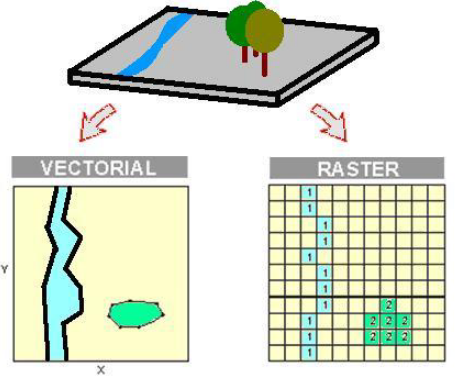

at least 3  applications (way more, be creative, use raster!):

1) over time: explain present with past, eg
redlining (vector) and contaminations: https://theaok.github.io/gis/gisGoodExampleOfFinalProject.pdf (vector, but redlining vector based on pictures/raster paper maps)

2) over time changes, eg melting ice caps https://earthengine.google.com/timelapse/

3) across space, eg
concrete in tx v nature in nj p43 https://drive.google.com/open?id=1Coj3CuwvzyoF2Rm_a0Fg5sSOXkTzuZlV


first images by hand (later API)

Just like for shapefile we googled "NJ counties shape file"
now we do sth like "NJ raster data download"

and so i found NJ dept of geog, and we pull raster data from:

https://newjersey.maps.arcgis.com/apps/webappviewer/index.html?id=d13ac68c0d0f46139673824bbf19ad66
zoom in click on tile and copy link to (geo)tif

In [ ]:
#using rasterio lib
#https://rasterio.readthedocs.io/en/latest/topics/plotting.html
#https://geopandas.org/en/stable/gallery/geopandas_rasterio_sample.html

!pip install rasterio
import rasterio
import matplotlib.pyplot as plt

In [ ]:
#1930 tile145
!wget -q -O tile145.tif https://njogis-imagery.s3-us-west-2.amazonaws.com/1930/cog/tile145.tif #this is url to img src
src = rasterio.open("tile145.tif")
src.bounds #note bounds, these would be coords on x and y

In [ ]:
%%capture
#del capture above just to make notebook smaller

fig, ax = plt.subplots(figsize=(20, 16))
ax.set_ylim([3000,2000]) #zoom onto waterfront
ax.set_xlim([2000,3000])
#ax.set_aspect(1/3)

ax.imshow(src.read(1)) #, aspect='auto',extent=[1500,5000,2000,20000]
#zorder=1,alpha=.6,interpolation='nearest'

#blurry, but still pretty awesome as for 1930!

In [ ]:
#250mb each! give it like 20sec to download
!wget -q -O D13C14-07.tif https://njogis-imagery.s3-us-west-2.amazonaws.com/2007/cog/D13C14.tif
src07 = rasterio.open("D13C14-07.tif")
!wget -q -O D13C14-20.tif https://njogis-imagery.s3.us-west-2.amazonaws.com/2020/cog/D13C14.tif
src20 = rasterio.open("D13C14-20.tif")
#src07.bounds

In [ ]:
%%capture
#del capture above just to make notebook smaller

fig, ax = plt.subplots(figsize=(20, 20))
#ax.set_ylabel('price')
#ax.set_xlabel('sdsa')
ax.set_ylim([5000,0])
ax.set_xlim([0,2000])
#ax.set_aspect(1/3)

ax.imshow(src07.read(1)) #, aspect='auto',extent=[1500,5000,2000,20000]
#zorder=1,alpha=.6,interpolation='nearest'

In [ ]:
%%capture
#del capture above just to make notebook smaller

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True,figsize=(20, 20)) #1row2col
axs[0].imshow(src07.read(1))
axs[1].imshow(src20.read(1))
axs[0].set_ylim([5000,0])
axs[0].set_xlim([0,2000])
axs[1].set_ylim([5000,0])
axs[1].set_xlim([0,2000])
axs[0].set_title('2007 prison, ru stadium')
axs[1].set_title('2020 american water, hilton');

btw google street view has time too! eg:<br>
https://www.google.com/maps/place/401+Cooper+St,+Camden,+NJ+08102/@39.9471578,-75.1218999,3a,75y,14.87h,90t/data=!3m7!1e1!3m5!1sITXQj8a5aM3Xj91QOfu4Fw!2e0!6s%2F%2Fgeo0.ggpht.com%2Fcbk%3Fpanoid%3DITXQj8a5aM3Xj91QOfu4Fw%26output%3Dthumbnail%26cb_client%3Dsearch.gws-prod%2Fmaps%2Flocal-details-getcard.gps%26thumb%3D2%26w%3D86%26h%3D86%26yaw%3D14.87242%26pitch%3D0%26thumbfov%3D100!7i13312!8i6656!4m5!3m4!1s0x89c6c8f0e64a7e77:0xb5b160dc340e83ec!8m2!3d39.9473113!4d-75.121837

### [oct22][*] raster+vector (careful with crs)


In [ ]:
! wget -q -O nj-counties.zip https://docs.google.com/uc?id=1xJDhcRCkgv7k4tNCa72Oog5bohV6dTB2&export=download
zip_ref = zipfile.ZipFile('nj-counties.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
njC0=gpd.read_file('nj_counties.shp') #
c=njC0[njC0.COUNTY=="CAMDEN"] #camden county

! wget -q -O tracts.zip https://github.com/theaok/data/raw/main/tl_2019_34_tract.zip
zip_ref = zipfile.ZipFile('tracts.zip', 'r'); zip_ref.extractall(); zip_ref.close() #just unzipping
tracts=gpd.read_file('tl_2019_34_tract.shp')
tractsCam=tracts[tracts.COUNTYFP=='007'] #tracts in camden county

In [ ]:
%%capture
!wget -q -O tile145.tif https://njogis-imagery.s3-us-west-2.amazonaws.com/1930/cog/tile145.tif #this is url to img src
src = rasterio.open("tile145.tif")
src.bounds #note extent (and in map's axes) x:300-330k y: 385k-420k
fig, ax = plt.subplots(figsize=(20, 10))
#ax.set_ylim([10000,1000]) #[3000,2000]
#ax.set_xlim([1000,10000]) #
#ax.set_aspect(1/3)
from rasterio.plot import show
rasterio.plot.show(src, ax=ax,)

In [ ]:
src.crs

In [ ]:
c.crs #projected has 'weird corrds' in thousands

In [ ]:
c.plot() #our vector c coords matche raster src, so can map straight up

In [ ]:

fig, ax = plt.subplots(figsize=(20, 10))
from rasterio.plot import show
rasterio.plot.show(src, ax=ax,) #, cmap="pink"
#ax.imshow(src.read(1))
c.plot(ax=ax,edgecolor='red',linewidth=1, facecolor="none")

In [ ]:
%%capture
#doesnt overlap! so crs problem!!
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_ylim([385000,420000]) #[3000,2000]
ax.set_xlim([310000,330000]) #

from rasterio.plot import show
rasterio.plot.show(src, ax=ax,) #, cmap="pink"
#ax.imshow(src.read(1))
tractsCam.plot(ax=ax,edgecolor='white',linewidth=1, facecolor="none")

In [ ]:
tractsCam.crs #geographic is lat -90 - 90 and lon -180 to 180

In [ ]:
tractsCam2 = tractsCam.to_crs(c.crs) #so have to transform (using c county from earlier that worked)
#tractsCam3 = tractsCam.to_crs(src20.crs) #can use newer raster to transform vector too

In [ ]:
%%capture
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_ylim([385000,420000]) #[3000,2000]
ax.set_xlim([310000,330000]) #

from rasterio.plot import show
rasterio.plot.show(src, ax=ax,) #, cmap="pink"
#ax.imshow(src.read(1))
tractsCam2.plot(ax=ax,edgecolor='purple',linewidth=3, facecolor="none")

### [*] goog raster (API) [complicated]

there's a ton! landsat, sentinel among others
see https://developers.google.com/earth-engine/datasets/ (temp, climate, etc)

landsat and sentinel major satelite images as far as i can tell (i don't really use raster in my own work so far unfortuntalely)



In [ ]:
#https://developers.google.com/earth-engine/guides/python_install
import ee
ee.Authenticate()
ee.Initialize(project='elaborate-karma-195918')#!! you need to register your own at https://console.cloud.google.com/earth-engine/configuration/manage-registration
print(ee.String('Hello from the Earth Engine servers!').getInfo())

#### landsat tutorial

In [ ]:
landsat_collection = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') #can figure out from above url documentation
#landsat_collection = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')  # Landsat 7 raw images collection
#landsat_collection = ee.ImageCollection("LANDSAT/LC08/C02/T1_SR")

In [ ]:
#apparently needs to rescale stuff, otherwhise im getting white square; following:
#https://gis.stackexchange.com/questions/473155/landsat-imagery-showing-up-as-white-in-gee
#https://gis.stackexchange.com/questions/421643/scale-factors-application-not-working-on-gee-pyqgis
#https://developers.google.com/earth-engine/landsat_c1_to_c2

# Applies scaling factors.
def apply_scale_factors(image):
  optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
  thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
  return image.addBands(optical_bands, None, True).addBands(
      thermal_bands, None, True
  )


In [ ]:
    # Filter by date
    filtered_collection = landsat_collection.filterDate('2023-01-01', '2023-12-31').map(apply_scale_factors)

    # Filter by a region (example: a point and buffer)
    point = ee.Geometry.Point([-74.0060, 40.7128]) # Example: New York City
    region_of_interest = point.buffer(10000) # 10 km buffer
    filtered_collection = filtered_collection.filterBounds(region_of_interest)

    # Select a single image (e.g., the least cloudy)
    image = filtered_collection.sort('CLOUD_COVER').first()

    # Or create a median composite
    # image = filtered_collection.median()

In [ ]:
import geemap #basemap to orient ourselves where we are
#        vis_params = {
#        'bands': ['SR_B4', 'SR_B3', 'SR_B2'], # Red, Green, Blue bands for true color
#        'min': 0,
#        'max': 3000, # Adjust max based on your data and desired contrast
#        'gamma': 1.4 # Optional gamma correction
#    }

#visualization parameters--read the documentation, i just took from tutorial these values
vis_params = {'bands': ['SR_B5','SR_B4','SR_B3'],
              'min': 0,
              'max': 0.3}

m = geemap.Map()
m.centerObject(region_of_interest, 10) # Center the map on your region
m.addLayer(image, vis_params, 'Landsat Image')
m # Display the map

In [ ]:
landsat_collection = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    # Example: filter by date and bounds
filtered_image = landsat_collection.filterDate('2023-01-01', '2023-12-31') \
                                   .filterBounds(ee.Geometry.Point(-122.4, 37.7)) \
                                   .sort('CLOUD_COVER') \
                                   .map(apply_scale_factors)  \
                                   .first()

#vis_params = {
#    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],  # Red, Green, Blue bands for true color
#    'min': 0,
#    'max': 3000,
#    'gamma': 1.4
#}

vis_params = {'bands': ['SR_B5','SR_B4','SR_B3'],
              'min': 0,
              'max': 0.3}

m = geemap.Map()
m.centerObject(filtered_image, 10)
m.addLayer(filtered_image, vis_params, 'Landsat Image')
m

In [ ]:
m = geemap.Map(center=[33, -87], zoom=8)

#Dates for imagery acquisition
i_date = '2020-01-01'
f_date = '2020-12-30'

#AOI point in Alabama
my_AOI = ee.Geometry.Point([-87, 33])

#Fetching Landsat 8 RGB as ee Image Collection for 2020
landsat = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterDate(i_date,f_date)
    .filterBounds(my_AOI)
    # Adjust each image in the collection to the correct range
    .map(apply_scale_factors)
    .min()
)

#Corresponding bands for L8
red = landsat.select("SR_B4")
green = landsat.select("SR_B3")
blue = landsat.select("SR_B2")

rgb_params = {'bands': ['SR_B5','SR_B4','SR_B3'],
              'min': 0,
              'max': 0.3}
m.addLayer(landsat, rgb_params, 'Landsat Image')
#m.addLayer(landsat, vis_params, 'Landsat Image')
m

there's another totorial here and looks useful--can get good looking images, not reddish stuff like above
https://climada-python.readthedocs.io/en/stable/user-guide/climada_util_earth_engine.html

In [ ]:
# Access a specific image
image = ee.Image("LANDSAT/LC08/C01/T1_TOA/LC08_044034_20140318")
# Landsat 8 image, with Top of Atmosphere processing, on 2014/03/18

# Access a collection
collection = "LANDSAT/LE07/C01/T1"  # Landsat 7 raw images collection

## skip the rest for now!!!

#### goog tutorial
https://developers.google.com/earth-engine/tutorials/community/intro-to-python-api


In [ ]:
# Import the MODIS land cover collection.
lc = ee.ImageCollection('MODIS/006/MCD12Q1')

# Import the MODIS land surface temperature collection.
lst = ee.ImageCollection('MODIS/006/MOD11A1')

# Import the USGS ground elevation image.
elv = ee.Image('USGS/SRTMGL1_003')

In [ ]:
# Initial date of interest (inclusive).
i_date = '2017-01-01'

# Final date of interest (exclusive).
f_date = '2020-01-01'

# Selection of appropriate bands and dates for LST.
lst = lst.select('LST_Day_1km', 'QC_Day').filterDate(i_date, f_date)

In [ ]:
# Define the urban location of interest as a point near Lyon, France.
u_lon = 4.8148
u_lat = 45.7758
u_poi = ee.Geometry.Point(u_lon, u_lat)

# Define the rural location of interest as a point away from the city.
r_lon = 5.175964
r_lat = 45.574064
r_poi = ee.Geometry.Point(r_lon, r_lat)

In [ ]:
scale = 1000  # scale in meters

# Print the elevation near Lyon, France.
elv_urban_point = elv.sample(u_poi, scale).first().get('elevation').getInfo()
print('Ground elevation at urban point:', elv_urban_point, 'm')

# Calculate and print the mean value of the LST collection at the point.
lst_urban_point = lst.mean().sample(u_poi, scale).first().get('LST_Day_1km').getInfo()
print('Average daytime LST at urban point:', round(lst_urban_point*0.02 -273.15, 2), '°C')

# Print the land cover type at the point.
lc_urban_point = lc.first().sample(u_poi, scale).first().get('LC_Type1').getInfo()
print('Land cover value at urban point is:', lc_urban_point)

In [ ]:
# Define a region of interest with a buffer zone of 1000 km around Lyon.
roi = u_poi.buffer(1e6)

# Reduce the LST collection by mean.
lst_img = lst.mean()

# Adjust for scale factor.
lst_img = lst_img.select('LST_Day_1km').multiply(0.02)

# Convert Kelvin to Celsius.
lst_img = lst_img.select('LST_Day_1km').add(-273.15)

from IPython.display import Image

# Create a URL to the styled image for a region around France.
url = lst_img.getThumbUrl({
    'min': 10, 'max': 30, 'dimensions': 512, 'region': roi,
    'palette': ['blue', 'yellow', 'orange', 'red']})
print(url)

# Display the thumbnail land surface temperature in France.
print('\nPlease wait while the thumbnail loads, it may take a moment...')
Image(url=url)

In [ ]:
# Make pixels with elevation below sea level transparent.
elv_img = elv.updateMask(elv.gt(0))

# Display the thumbnail of styled elevation in France.
Image(url=elv_img.getThumbURL({
    'min': 0, 'max': 2000, 'dimensions': 512, 'region': roi,
    'palette': ['006633', 'E5FFCC', '662A00', 'D8D8D8', 'F5F5F5']}))

#### temp geemap example

In [ ]:
import geemap

jan_2023_climate = (
    ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
    .filterDate('2023-01', '2023-02')
    .first()
)

# Instantiate a geemap Map object
m = geemap.Map(center=[30, 0], zoom=2)

# Define visualization parameters for the temperature band
vis_params = {
    'bands': ['temperature_2m'],
    'min': 229,  # Minimum temperature in Kelvin
    'max': 304,  # Maximum temperature in Kelvin
    'palette': 'inferno', # Color palette for visualization
}

# Add the temperature band as a layer to the map
m.add_layer(jan_2023_climate, vis_params, 'Temperature (K)')

# Display the map (this will open an interactive map if run in a Jupyter-like environment)
m

#### other APIa and other ideas
can get sat img straight to python, via API, eg

https://carpentries-incubator.github.io/geospatial-python/

https://sites.northwestern.edu/researchcomputing/2021/11/19/downloading-satellite-images-made-easy/

https://earthengine.google.com/timelapse/
very cool lets do default Columbia glacier 84 v 22 (pause; by hand)

and las vegas, same contrast, note less water, too (others:  urban growth, deforestation, etc)


check out Global Gridded Relative Deprivation Index (GRDI)
https://www.earthdata.nasa.gov/news/feature-articles/measuring-relative-poverty-deprivation-around-globe

# for nat sci people

https://www.pyngl.ucar.edu/Examples/gallery.shtml

https://cdat.llnl.gov/gallery.html

# notes to myself

### fa24

### 2023

TODO if anything go thru gpd again esp as more features being added!
<br>

the whole course, geo dat sci: [oct2023 not super urgent; skimmed thru it already]
https://darribas.org/gds_course/content/home.html

<br>oct2023 found 1 more; already incorporated most useful stuff , still  a useful reference:

old  version:
https://automating-gis-processes.github.io/CSC/index.html

new version:
https://autogis-site.readthedocs.io/en/latest/



<br>
LATER/MAYBE: [oct2023 but meh not clear advantage over gpd/folium]
 basemap! guess the first one! used to use it, but dead, depreciated in favor of cartopy
https://jakevdp.github.io/PythonDataScienceHandbook/04.13-geographic-data-with-basemap.html